In [1]:
%cd ..
import os


import torch as tn
import torchtt as tntt
import teneva as ten
import numpy as np
from time import time
import json

from src.qtt_interpolation.utils import *
from src.qtt_interpolation.int_tools import *
import pandas as pd
from metrics.mutils import*
from scipy.optimize import minimize_scalar

/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


In [2]:
import torch

def symmetric_wing(x: torch.Tensor,
                   y: torch.Tensor,
                   rad: float,
                   new='swing') -> torch.Tensor:
    """
    x, y: same‐shaped tensors of coordinates (e.g. from meshgrid)
    rad: radius factor (you had t = 10*rad)
    new: `"wing1"` or other, controls the k‐shift
    returns: bump values = exp(-1e4 * (v^2 - (y - k*(arg-0.5))^2 + |...|))
    """
    # thickness parameter
    t = 10.0 * rad
    # horizontal shift
    x0 = -.5
    y0 = 0

    y = y-y0

    # small camber if "wing1"
    k = 0.4 if new == "wing1" else 0.0

    # polynomial coefficients
    csq = 0.2969 * t
    c1, c2, c3, c4 = (-0.1260*t, -0.3516*t, 0.2843*t, -0.1015*t)

    # compute "arg" with the domain test |x - 0.5 - x0| <= 0.5
    cond = (torch.abs(x - 0.5 - x0) <= 0.5)
    outside = torch.sign(x0 - x) + torch.sign(x - x0 - 1)
    arg = torch.where(cond, x - x0, outside)

    # ensure non-negative for sqrt
    arg_s = torch.clamp(arg, min=0.0)

    # profile v(arg)
    v = (c1*arg + c2*arg**2 + c3*arg**3 + c4*arg**4
         + csq * torch.sqrt(arg_s))

    # raw signed distance squared difference
    raw = v**2 - (y - k*(arg - 0.5))**2

    # keep only positive part (so values ≥ 0)
    pos = raw + torch.abs(raw)

    # final bump
    return torch.exp(-1e2 * pos)


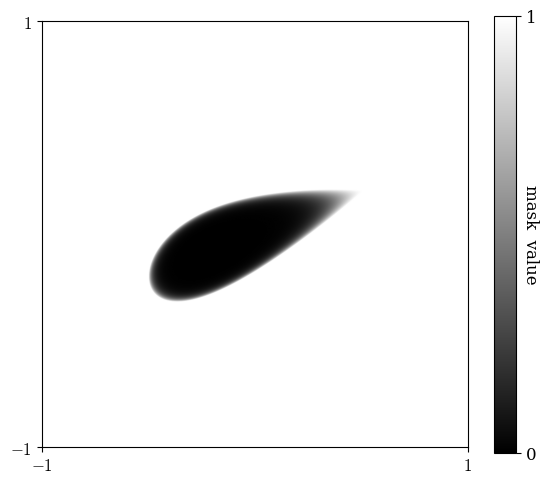

In [2]:

# ─── MathText (builtin LaTeX) settings ─────────────────────
plt.rc('font',      family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# parameters
p, rad, new = 10, 0.2, "wing1"
nx, ny = 2**p, 2**p
xs = tn.linspace(-1, 1, nx+1, dtype=tn.float64)[:-1]
ys = tn.linspace(-1, 1, ny+1, dtype=tn.float64)[:-1]
X, Y = tn.meshgrid(xs, ys, indexing="xy")
Z   = symmetric_wing(X, Y, rad=rad, new=new)

# ─── Plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(Z,
               origin="lower",
               extent=[-1,1,-1,1],
               aspect="equal",
               cmap="gray")

# colorbar with 3 ticks and mathtext label
cbar = fig.colorbar(im, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_label(r'mask  value',
               rotation=270,
               labelpad=2,
               fontsize=12)

# exactly two ticks on each axis
ax.set_xticks([-1, 1])
ax.set_yticks([-1, 1])
ax.set_xticklabels([r'$-1$', r'$1$'], fontsize=12)
ax.set_yticklabels([r'$-1$', r'$1$'], fontsize=12)

# bold mathtext title
#ax.set_title(r'$\mathbf{Wing\ Bump\ Heatmap}$', pad=0, fontsize=16)

plt.tight_layout()
fig.savefig('./metrics/plots/wing.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
Zsvd = tntt.TT(zM(Z,p),[2,2]*p,eps=1e-6)
Zsvd

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, np.int64(6), np.int64(6), np.int64(10), np.int64(12), np.int64(20), np.int64(31), np.int64(51), np.int64(63), np.int64(93), np.int64(102), np.int64(127), 64, 32, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 90122 compression 0.08594703674316406

In [22]:
(zM(Z,p) - Zsvd.full().reshape(2**p,2**p) ).norm()/Z.norm()

tensor(0.0016, dtype=torch.float64)

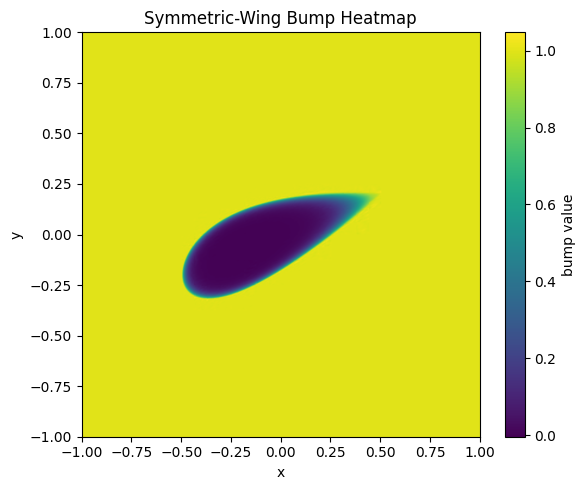

In [12]:
plt.figure(figsize=(6,5))
plt.imshow(z_order_to_normal_torch(Zsvd.full().flatten(),2**p,2**p).t(), origin="lower", extent=[-1,1,-1,1], aspect="auto")
plt.colorbar(label="bump value")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Symmetric-Wing Bump Heatmap")
plt.tight_layout()
plt.show()

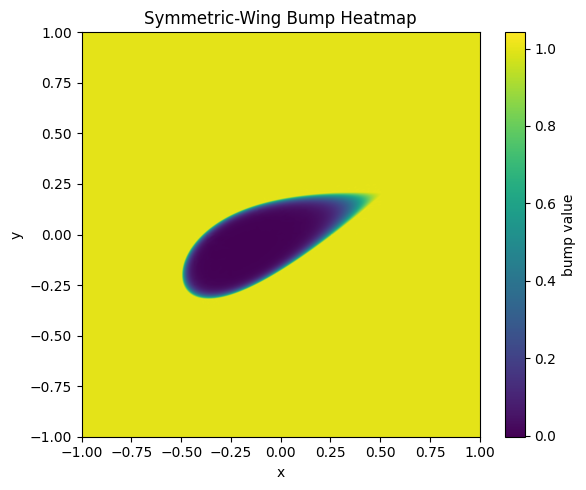

In [30]:
ZI = qtt_skcubic2d_p(Zsvd, 11, eps=1e-12, order=1).round(eps=1e-3)
plt.figure(figsize=(6,5))
plt.imshow(z_order_to_normal_torch(ZI.full().flatten(),2**(p+1),2**(p+1)).t(), origin="lower", extent=[-1,1,-1,1], aspect="auto")
plt.colorbar(label="bump value")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Symmetric-Wing Bump Heatmap")
plt.tight_layout()
plt.show()

In [31]:
ZI

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 5, 5, 8, 10, 18, 24, 37, 42, 52, 42, 33, 22, 15, 10, 7, 5, 4, 3, 2, 1]

Device: cpu, dtype: torch.float64
#entries 20668 compression 0.004927635192871094

In [59]:
ten.show([c.numpy() for c in Zsvd.cores])

TT-tensor    20D : |2| |2| |2| |2| |2| |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2| |2| |2| |2| |2|
<rank>  =   25.4 :   \2/ \4/ \5/ \5/ \8/ \10/ \18/ \24/ \37/ \42/ \55/ \46/ \42/ \25/ \15/ \8/ \6/ \4/ \2/


In [344]:
n = [ 2,2]*p   # Shape of the tensor
m         = None  # Number of calls to target function
e         =  1e-10   # Desired accuracy
nswp      = 4  # Sweep number
r         = 30     # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows)
dr_max    = 5      # Cross parameter (maximum number of added rows)

def f(I):
    X = ind_to_r_ten(I,a=-1,b=1,d=2,pdp=1)
    x,y = X[:,0], X[:,1]
    return symmetric_wing( tn.tensor(x,dtype=tn.float64), tn.tensor(y,dtype=tn.float64),rad=rad,new='wing1' )

Y = ten.rand(n, r)
info_fine,cache = {}, {}
Y = ten.cross(f, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max, cache=cache,log=True,info=info_fine,m_cache_scale=10)
Yr = ten.truncate(Y, 1e-8)
ten.show(Yr)


# pre | time:      0.057 | evals: 0.00e+00 (+ 0.00e+00) | rank:  30.0 | 
#   1 | time:      3.921 | evals: 2.15e+04 (+ 3.02e+04) | rank:  30.1 | e: 1.0e+00 | 
#   2 | time:      9.802 | evals: 3.41e+04 (+ 9.31e+04) | rank:  35.5 | e: 1.2e-02 | 
#   3 | time:     18.128 | evals: 4.80e+04 (+ 1.82e+05) | rank:  40.9 | e: 7.1e-03 | 
#   4 | time:     32.478 | evals: 6.30e+04 (+ 3.01e+05) | rank:  46.1 | e: 3.7e-03 | stop: nswp | 
TT-tensor    20D : |2| |2| |2| |2| |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2|  |2| |2| |2| |2|
<rank>  =   39.2 :   \2/ \4/ \6/ \6/ \11/ \13/ \20/ \31/ \56/ \62/ \70/ \70/ \70/ \64/ \32/ \16/ \8/ \4/ \2/


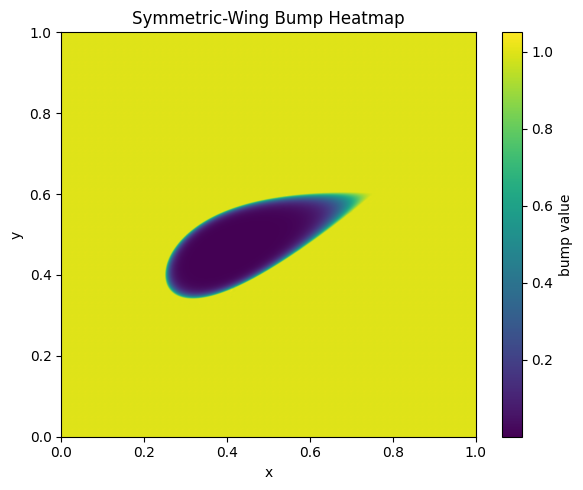

In [345]:


Zcross = z_order_to_normal(ten.full(Yr).ravel(),2**p,2**p).T

# plot
plt.figure(figsize=(6,5))
plt.imshow(Zcross, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.colorbar(label="bump value")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Symmetric-Wing Bump Heatmap")
plt.tight_layout()
plt.show()

In [346]:
Znp = Z.cpu().numpy()
norm = np.linalg.norm(Znp)

print( np.linalg.norm(Zcross-Znp)/norm )

0.001941227079466055


In [347]:
ZSVD = z_order_to_normal_torch(Zsvd.full().flatten(),2**p,2**p).t().numpy()

print( np.linalg.norm(ZSVD-Znp)/norm )

5.0028701065020716e-05


In [175]:
z_order_to_normal_torch(Zsvd.full().flatten(),2**p,2**p).t().max()

tensor(1.3798)